<a href="https://colab.research.google.com/github/RiverAlpha/DL/blob/main/11_8_Transformers_for_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# VIT

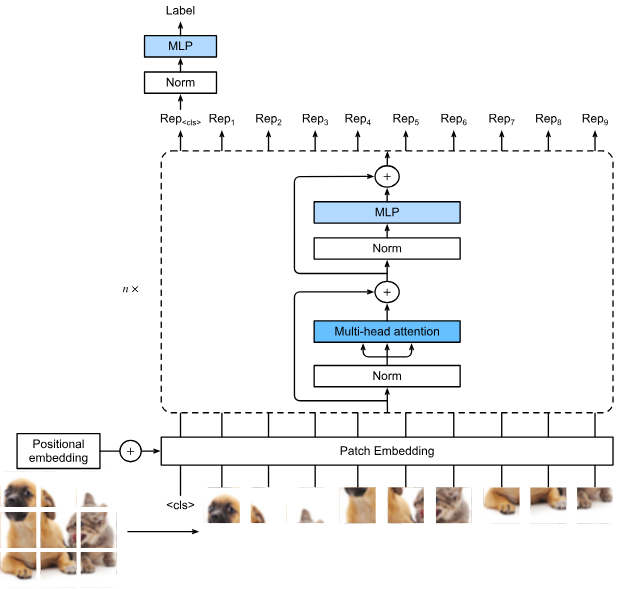

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=256, img_size=32):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2  # (32 // 4)^2 = 64
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim)) # [1, 65, 256]

    def forward(self, x):
        # 初始输入 x 形状: [B, 3, 32, 32]
        B = x.shape[0]

        # 第一步: self.proj(x) 卷积切块
        # [B, 3, 32, 32] -> [B, 256, 8, 8]  (空间维度从32缩减为32/4=8)
        #
        # 第二步: .flatten(2) 展平空间网格
        # [B, 256, 8, 8] -> [B, 256, 64]    (8*8=64，把高度和宽度拉平)
        #
        # 第三步: .transpose(1, 2) 维度交换，变为标准序列
        # [B, 256, 64] -> [B, 64, 256]      (64个Token，每个维度256)
        x = self.proj(x).flatten(2).transpose(1, 2)

        # 扩展 [CLS] Token 匹配当前 Batch Size
        # [1, 1, 256] -> [B, 1, 256]
        cls_tokens = self.cls_token.expand(B, -1, -1)

        # 沿着序列维度(dim=1)拼接 [CLS] Token 和 图像 Patch
        # [B, 1, 256] concat [B, 64, 256] -> [B, 65, 256]
        x = torch.cat((cls_tokens, x), dim=1)

        # 加上位置编码 (利用广播机制给每一个 Batch 加上相同的编码)
        # [B, 65, 256] + [1, 65, 256] -> [B, 65, 256]
        return x + self.pos_embed

In [13]:
class ViT(nn.Module):
  def __init__(self, img_size=32, patch_size=4, num_classes=10,embed_dim = 256,depth = 6, heads = 8):
    super().__init__()
    self.patch_embed = PatchEmbedding(patch_size=patch_size, embed_dim=embed_dim, img_size=img_size)
    encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim*4, batch_first=True)
    self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
    self.norm = nn.LayerNorm(embed_dim)
    self.head = nn.Linear(embed_dim, num_classes)

  def forward(self, x):
    x = self.patch_embed(x)
    x = self.transformer(x)
    return self.head(self.norm(x[:, 0]))

# dataloders

In [5]:
def get_dataloaders(batch_size=64):
  transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
      ]) #标准化到[-1,1]
  trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
  trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

  testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
  testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
  classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
  return trainloader, testloader, classes


# train

In [6]:
def train_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    trainloader, testloader, classes = get_dataloaders(batch_size=128)

    # 实例化模型
    model = ViT(img_size=32, patch_size=4, num_classes=10, embed_dim=256, depth=6, heads=8).to(device)

    # ViT 训练推荐使用 AdamW 和 CrossEntropyLoss
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

    epochs = 5 # 演示用，仅跑5个Epoch
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            # 前向传播 + 反向传播 + 优化
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 100 == 99:
                print(f"[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}")
                running_loss = 0.0

    print("Finished Training")
    return model, classes

# 推理

In [7]:
# ==========================================
# 4. 推理过程 (Inference)
# ==========================================
def inference(model, classes):
    device = next(model.parameters()).device
    model.eval() # 务必切到评估模式

    # 构造一张假图片模拟真实的单张输入 (比如读取了一张 32x32 的 RGB 图像)
    # 注意：推理时往往是单张图，但模型要求包含 Batch 维度，所以需要 unsqueeze(0)
    dummy_image = torch.randn(1, 3, 32, 32).to(device)

    with torch.no_grad(): # 推理时不计算梯度，节省显存并加速
        output = model(dummy_image) # shape: [1, 10]

        # 使用 softmax 获取置信度概率
        probabilities = torch.nn.functional.softmax(output[0], dim=0)

        # 找到概率最大的类别索引
        predicted_idx = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_idx].item()

        print("\n--- 推理结果 ---")
        print(f"预测类别: {classes[predicted_idx]}")
        print(f"置信度: {confidence * 100:.2f}%")

In [14]:
if __name__ == "__main__":
    trained_model, class_names = train_model()
    inference(trained_model, class_names)

Using device: cuda
[Epoch 1, Batch 100] loss: 2.117
[Epoch 1, Batch 200] loss: 1.863
[Epoch 1, Batch 300] loss: 1.700
[Epoch 2, Batch 100] loss: 1.496
[Epoch 2, Batch 200] loss: 1.459
[Epoch 2, Batch 300] loss: 1.401
[Epoch 3, Batch 100] loss: 1.304
[Epoch 3, Batch 200] loss: 1.301
[Epoch 3, Batch 300] loss: 1.275
[Epoch 4, Batch 100] loss: 1.177
[Epoch 4, Batch 200] loss: 1.196
[Epoch 4, Batch 300] loss: 1.183
[Epoch 5, Batch 100] loss: 1.081
[Epoch 5, Batch 200] loss: 1.090
[Epoch 5, Batch 300] loss: 1.087
Finished Training

--- 推理结果 ---
预测类别: frog
置信度: 51.75%
